# Generative Adversarial Network (GANs)
Sieci generatywne są użytecznym narzędziem, które może być wykorzystywane np. do generowania realistycznych danych w oparciu o istniejący zbiór. 

W ramach tego typu trenujemy dwa modele:
 - model generujący (generator) - tworzący dane na podstawie przykładów (np. obraz)
 - model oceniający (dscrimminator) - klasyfikujący przykłady jako prawdziwe bądź wygenreowane

Obie sieci są trenowane równolegle na zasadzie współzawodnictwa, co przy kolejnych iteracjach pozwala na generowanie przykładów lepiej oddających rzeczywisty zbiór danych. Po wytrenowaniu sieci rezultaty jej działania można np. wykorzystać do rozszerzenia zbioru trenującego dla innych modeli (np. w przypadkach gdy nie mamy dość danych, by wytrenować sieć do naszego rozwiązania). 

W ramach przykładu wykorzystamy zbiór danych MNIST do generacji odręcznie pisanych liczb. Jak przy każdym przykładzie, zaczynamy od importu potrzebnych bibliotek.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

W pierwszej kolejności tworzymy klasę do generatora. 

In [4]:
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.main = nn.Sequential(
            nn.Linear(noise_dim, 7 * 7 * 256),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7, 7)),
            nn.ConvTranspose2d(256, 128, 5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, stride=2,
                               padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 5, stride=2,
                               padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

Drugim modelem, któego potrzebujemy jest model oceniający. Na wyjściu mamy tu w pełni połaczoną warstwę pokazującą czy podany obrazek jest prawdziwy czy wygenerowany. 

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
            nn.Flatten(),
            nn.Linear(7 * 7 * 128, 1)
        )

    def forward(self, x):
        return self.main(x)

Kolejnym krokiem jest utworzenie obu modeli. W początkowych iteracjach generator będzie wykorzystywał szum losowy do tworzenia obrazów. Przy kolejnych iteracjach uczenia powinien nauczyć się charakterystyki zbioiru danych i generować obrazki co raz bliższe rzeczywistym. Oczywiście nie zapominamy również o wybraniu odpowiedniego użądzenia do obliczeń (CPU lub GPU), oraz podpięciu pod nie obu modeli.

In [6]:
NOISE_DIM = 100

generator = Generator(NOISE_DIM)
discriminator = Discriminator()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = generator.to(device)
discriminator = discriminator.to(device)

W kolejnym kroku ustawiamy dodatkowe elementy, takie jak funkcja straty, optymizacja oraz inicjalizujemy hyperparametry modelu.

In [7]:
criterion = nn.BCEWithLogitsLoss()

generator_optimizer = optim.Adam(
    generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

NUM_EPOCHS = 50
BATCH_SIZE = 256

Jako że będziemy trenować całość na zbiorze MNIST trzeba ten zbiór załadować i przygotować. 

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.14MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 251kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.9MB/s]


W tym momencie mamy już wszystko przygotowane i zostaje nam samo trenowanie modelu. W tym wypadku jest to nieco szybsze, można więc pozwolić sobie na więcej epok (u mnie dla 50-ciu epok model trenował się przez niecałe 3 minuty). Podczas trenowania sieci przepinamy się pomiędzy modelem generującym i oceniającym, aktualizując oba. Ogólnie dla każdej epoki przechodzimy przez serię plików wejściowych, trenujemy model oceniający na prawdziwych i wygenerowanych obrazach z przypisanymi klasami, następnie generator tworzy obrazy próbując "oszukać" model oceniający, całość powtarzamy, monitorując parametry obu modeli.

Oba wytrenowane modele z wagami można zapisać, w celu późniejszego wykorzystania.

In [10]:
for epoch in range(NUM_EPOCHS):
    for i, data in enumerate(train_loader):
        real_images, _ = data
        real_images = real_images.to(device)

        discriminator_optimizer.zero_grad()
        real_labels = torch.ones(real_images.size(0), 1, device=device)
        real_outputs = discriminator(real_images)
        real_loss = criterion(real_outputs, real_labels)
        real_loss.backward()

        noise = torch.randn(real_images.size(0), NOISE_DIM, device=device)
        fake_images = generator(noise)
        fake_labels = torch.zeros(real_images.size(0), 1, device=device)
        fake_outputs = discriminator(fake_images.detach())
        fake_loss = criterion(fake_outputs, fake_labels)
        fake_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()
        fake_labels = torch.ones(real_images.size(0), 1, device=device)
        fake_outputs = discriminator(fake_images)
        gen_loss = criterion(fake_outputs, fake_labels)
        gen_loss.backward()
        generator_optimizer.step()

        if i % 100 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{len(train_loader)}], '
                  f'Discriminator Loss: {real_loss.item() + fake_loss.item():.4f}, '
                  f'Generator Loss: {gen_loss.item():.4f}')
            
#Saving created models         
torch.save(generator, "GAN_Generator")
torch.save(discriminator, "GAN_Discriminator")

Epoch [1/50], Step [1/235], Discriminator Loss: 1.4659, Generator Loss: 1.2230
Epoch [1/50], Step [101/235], Discriminator Loss: 0.1782, Generator Loss: 4.1330
Epoch [1/50], Step [201/235], Discriminator Loss: 0.0662, Generator Loss: 4.1651
Epoch [2/50], Step [1/235], Discriminator Loss: 0.0709, Generator Loss: 4.7524
Epoch [2/50], Step [101/235], Discriminator Loss: 0.0229, Generator Loss: 4.8813
Epoch [2/50], Step [201/235], Discriminator Loss: 0.0188, Generator Loss: 5.1137
Epoch [3/50], Step [1/235], Discriminator Loss: 0.0176, Generator Loss: 5.1662
Epoch [3/50], Step [101/235], Discriminator Loss: 0.0309, Generator Loss: 5.3508
Epoch [3/50], Step [201/235], Discriminator Loss: 0.0176, Generator Loss: 5.8456
Epoch [4/50], Step [1/235], Discriminator Loss: 0.0143, Generator Loss: 5.2048
Epoch [4/50], Step [101/235], Discriminator Loss: 0.0071, Generator Loss: 5.4859
Epoch [4/50], Step [201/235], Discriminator Loss: 0.0107, Generator Loss: 5.8070
Epoch [5/50], Step [1/235], Discrimi

Ostatnim krokiem jest wizualizacja - poniższa metoda umożliwia wygenerowanie i wyświetlenie przykładowych, wygenerowanych obrazów w celu zweryfikowania jak blisko oryginalnych przykładów się znajdują. 

In [12]:
def generate_and_save_images(model, epoch, noise):
    model.eval()
    with torch.no_grad():
        fake_images = model(noise).cpu()
        fake_images = fake_images.view(fake_images.size(0), 28, 28)

        fig = plt.figure(figsize=(4, 4))
        for i in range(fake_images.size(0)):
            plt.subplot(4, 4, i + 1)
            plt.imshow(fake_images[i], cmap='gray')
            plt.axis('off')

        plt.savefig(f'image_at_epoch_{epoch+1:04d}.png')
        plt.show()

W plikach znajdują się 3 wersje modeli:
 - trenowae przez 50 epok
 - trenowane przez 100 epok i
 - trenowane przzez 200 epok. 

Poniższe wyniki obrazują działanie poszczególnych z nich. 

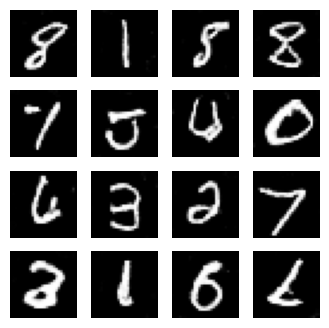

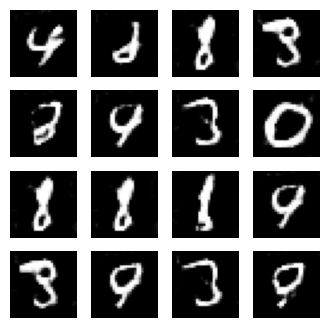

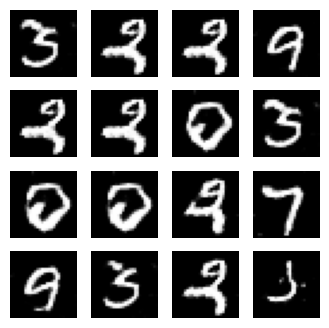

In [22]:
generator50 = torch.load("GAN_Generator", weights_only=False)
generator100 = torch.load("GAN_Generator_100", weights_only=False)
generator200 = torch.load("GAN_Generator_200", weights_only=False)

test_noise = torch.randn(16, NOISE_DIM, device=device)

generate_and_save_images(generator50, 50, test_noise)       #Showing a set of generated images for 50 epochs
generate_and_save_images(generator100, 100, test_noise)      #Showing a set of generated images for 100 epochs
generate_and_save_images(generator200, 200, test_noise)      #Showing a set of generated images for 200 epochs

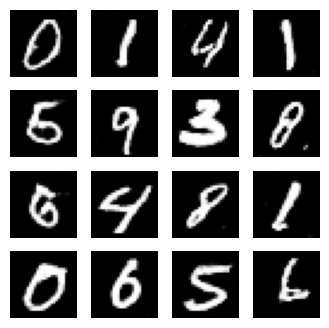

In [25]:
#Wersja bez ładowania modeli
test_noise = torch.randn(16, NOISE_DIM, device=device)
generate_and_save_images(generator, NUM_EPOCHS, test_noise)

Generowane przykłady mogą się mocno różnić pomiędzy kolejnymi uruchomieniami metod. Ogólnie na podstawie obrazów można stwierdzić, że modele wytrenowane na 50 i 100 epokach radzą sobie podobnie, przy czym model trenowany krócej częścej radzi sobie lepiej (w zależności od atualnych przykładów), natomiast model trenowany przez 200 epok jest zdecydowanie przetrenowany. 

Z punktu widzenia generowania dodatkowych danych np. w celu urozmaicenia zbioru do rozpoznawania ręcznie pisanych liczb, dwa pierwsze modele powinny spełniać swoją rolę.

Biorąc pod uwagę sytuacje, gdy nie mamy dużo dobrych danych do trenowania modelu, wytrenowanie sieci generatywnej do ich sztucznego wytworzenia może być dobrym rozwiązaniem, przy czym tak jak z każdym podejściem, należy zweryfikować wyniki działania pod kątem rozwiązywanego problemu i jego specyfiki. 

Oczywiście generacja może być też zadaniem samym w sobie (generacja obrazów i popularne ostatnio modele do tworzenia grafik na podstawie promptów użytkowników), przy czym jak łatwo zauważyć nawet na powyższych, stosunkowo prostych przykładach, stworzenie stabilnej i dobrej jakościowo sieci może być trudne, plus zawsze mamy ryzyko wystąpienia błędów przy generacji (wystarczy popatrzeć na co ciekawsze artefakty w modelach generatywnych dostępnych online).